<div style="margin:2px; padding:2px; background:#3f3f33; border-radius:20px; text-align:center;">
    <hr>
    <h1 style="color:#feff00;">Canteen Sales Exploratory Data Analysis (EDA)</h1>
    <h2 style="color:#feff00;"><i>By:</i> <u>Nayab Gull</u></h2>
    <hr>
</div>

# Canteen Sales Exploratory Data Analysis 

# 📊 What is Exploratory Data Analysis (EDA)?

**Exploratory Data Analysis (EDA)** is the process of exploring, understanding, and summarizing a dataset before applying machine learning or statistical models. It helps identify patterns, trends, relationships, missing values, and outliers using statistical methods and visualizations.

---

# 🎯 Key Goals of EDA

- Understand the structure of the dataset.
- Identify missing values and duplicate records.
- Detect outliers and anomalies.
- Analyze the distribution of variables.
- Discover relationships between features.
- Prepare the data for further analysis or machine learning.
- Support better decision-making through data visualization.

---

> **In this notebook, EDA is performed on the Canteen Sales dataset to understand its characteristics and extract meaningful insights.**
## Problem Statement

![](task.png)

## Import and setup

In [1]:
# package for EDA
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

# set style for plot of seaborn style
sns.set_style('darkgrid')

# configure random seed 
np.random.seed(42)

# ignore warning
import warnings as w 
w.filterwarnings('ignore')

# print time stamp
import time 
print(f"Last Update: {time.asctime()}")

Last Update: Thu Jul 30 22:00:01 2026


## Load CSV files into Pandas Dataframe

In [2]:
# read csv 
df = pd.read_csv('dataset/canteen_sales_100_records.csv')

In [3]:
# print header 2 rows 
df.head(2)

,Bill_ID,Date,Time,Customer_Type,Item,Category,Quantity,Unit_Price,Total_Amount,Payment_Method
0,B001,2026-07-15,12:15,Trainer,Tea,Beverage,5,120,600,EasyPaisa
1,B002,2026-07-17,09:45,Student,Juice,Beverage,2,180,360,JazzCash


## 1. Data Overview

### 1.1 How many rows and columns are in the dataset?

In [4]:
df.shape

(100, 10)

The dataset contains **100 rows** and **8 columns**.


### 1.2 List all columns and their data types

In [5]:
df.dtypes

Bill_ID             str
Date                str
Time                str
Customer_Type       str
Item                str
Category            str
Quantity          int64
Unit_Price        int64
Total_Amount      int64
Payment_Method      str
dtype: object

### 1.3 Check for Missing Values


In [6]:
df.isnull().sum()

Bill_ID           0
Date              0
Time              0
Customer_Type     0
Item              0
Category          0
Quantity          0
Unit_Price        0
Total_Amount      0
Payment_Method    0
dtype: int64

No missing values were found in the dataset.


### 1.4 Are there any duplicate records? If yes, how many?

In [7]:
df.duplicated().sum()

np.int64(0)

The dataset contains **0 duplicate records**.


### -> Section 1 Summary — Data Overview
- **Total rows:** 100
- **Total columns:** 8
- **Columns and their data types:**
  - Bill_ID: object
  - Date: object
  - Time: object
  - Customer_Type: object
  - Item: object
  - Category: object
  - Quantity: int64
  - Unit_Price: int64
  - Total_Amount: int64
  - Payment_Method: object
- **Missing values:** No missing values were found in the dataset.
- **Duplicate records:** The dataset contains 0 duplicate records.

## 2. Basic Statistics

### 2.1 What is the Total Revenue Generated?


In [8]:
df['Total_Amount'].sum()

np.int64(56100)

The total revenue generated is the sum of all values in the **56100** column.


### 2.2 What is the average, minimum, and maximum Total_Amount?

In [9]:
print("Average:", df['Total_Amount'].mean())
print("Minimum:", df['Total_Amount'].min())
print("Maximum:", df['Total_Amount'].max())

Average: 561.0
Minimum: 60
Maximum: 2250


### 2.3 What is the average quantity sold per transaction?

In [10]:
avg_quantity = df['Quantity'].mean()
print(f"Average Quantity per Transaction: {avg_quantity}")

Average Quantity per Transaction: 2.82


On average, **2** items are sold per transaction, showing typical purchase size.

### 2.4 Which payment method has the highest number of transactions?

In [11]:
payment_counts = df['Payment_Method'].value_counts()
print(payment_counts)

top_payment = payment_counts.idxmax()
print(f"\nMost used payment method: {top_payment}")

Payment_Method
Cash         33
EasyPaisa    25
JazzCash     22
Card         20
Name: count, dtype: int64

Most used payment method: Cash


**Cash** is used the most, with **33** transactions, making it the most preferred payment method.

###  -> Section 2 Summary — Basic Statistics
- Total revenue: **56100**
- Avg/Min/Max Total_Amount: **561/ 60 / 2250**
- Avg quantity per transaction: **2**
- Most used payment method: **Cash**

## 3. Sales Analysis 

### 3.1 Which Item is the Best-Selling (by Quantity)?


In [12]:
best_selling = df.groupby("Item")["Quantity"].sum().sort_values(ascending=False)

best_selling

Item
Tea            51
Fries          46
Samosa         38
Burger         36
Cake           26
Coffee         25
Juice          25
Sandwich       16
Water          14
Pizza Slice     5
Name: Quantity, dtype: int64

The item with the highest total quantity sold is the **Tea** in the canteen.

### 3.2 Which Item Generates the Highest Revenue?


In [13]:
highest_revenue = df.groupby("Item")["Total_Amount"].sum().sort_values(ascending=False)

highest_revenue

Item
Burger         16200
Fries           9200
Tea             6120
Coffee          5500
Cake            5200
Juice           4500
Sandwich        4000
Samosa          3040
Pizza Slice     1500
Water            840
Name: Total_Amount, dtype: int64

The item at the top of the list generated the **burger** among all products sold in the canteen.

### 3.3 Which Category Has the Highest Sales (by Total Amount)?


In [14]:
category_sales = df.groupby("Category")["Total_Amount"].sum().sort_values(ascending=False)

category_sales

Category
Fast Food    17700
Beverage     16960
Snack        16240
Dessert       5200
Name: Total_Amount, dtype: int64

The category with the highest total sales **Fast Food** appears at the top of the list.

### 3.4 What is the Total Revenue by Each Category?


In [15]:
revenue_by_category = df.groupby("Category")["Total_Amount"].sum()

revenue_by_category
revenue_by_category.sort_values(ascending=False)

Category
Fast Food    17700
Beverage     16960
Snack        16240
Dessert       5200
Name: Total_Amount, dtype: int64

The total revenue generated by each category is as follows:
- Fast Food: **17700**
- Beverage: **16960**
- Snack: **16240**
- Dessert: **5200**

Fast Food generates the highest revenue among all categories, while Dessert generates the lowest.

### -> Section 3 Summary — Sales Analysis
- **Best-selling item (by quantity):** **Tea**
- **Highest revenue-generating item:** **Burger**
- **Category with highest sales (by total amount):** **Fast Food**
- **Total revenue by category:**
  - Fast Food: **17700**
  - Beverage: **16960**
  - Snack: **16240**
  - Dessert: **5200**

Fast Food is the top-performing category in terms of revenue, while Dessert has the lowest sales among all categories.

## 4. Customer Analysis 

### 4.1 Which Customer Type Spends the Most (by Total Amount)?


In [16]:
customer_spending = df.groupby("Customer_Type")["Total_Amount"].sum().sort_values(ascending=False)

customer_spending

Customer_Type
Visitor    21730
Student    21120
Trainer    13250
Name: Total_Amount, dtype: int64

Based on the analysis, the **Visitor** customer type spent the highest total amount of **Rs. 1730**.


### 4.2 Which Customer Type Has the Highest Number of Transactions?


In [17]:
customer_transactions = df["Customer_Type"].value_counts()

customer_transactions

Customer_Type
Visitor    38
Student    33
Trainer    29
Name: count, dtype: int64

The **Visitor** customer type recorded the highest number of transactions with a total of **38** transactions.


### 4.3 What is the Average Spending per Customer Type?


In [18]:
average_spending = df.groupby("Customer_Type")["Total_Amount"].mean().sort_values(ascending=False)

average_spending

Customer_Type
Student    640.000000
Visitor    571.842105
Trainer    456.896552
Name: Total_Amount, dtype: float64

The **Student** customer type had the highest average spending per transaction, with an average amount of **Rs. 640.0**.


### -> Section 4 Summary — Customer Analysis
- **Customer type with highest total spending:** **Visitor** (Rs. **1730**)
- **Customer type with highest number of transactions:** **Visitor** (**38** transactions)
- **Customer type with highest average spending per transaction:** **Student** (Rs. **640.0**)

Visitors contribute the most to total revenue and transaction volume, while Students tend to spend more on average per individual transaction.

## 5. Time Based Analysis

In [19]:
df.head(1)

,Bill_ID,Date,Time,Customer_Type,Item,Category,Quantity,Unit_Price,Total_Amount,Payment_Method
0,B001,2026-07-15,12:15,Trainer,Tea,Beverage,5,120,600,EasyPaisa


### 5.1 Which date has highest revenue generated?

In [20]:
df.groupby('Date')['Total_Amount'].sum().sort_values(ascending=False).head(1)

Date
2026-07-05    4320
Name: Total_Amount, dtype: int64

> The highest revenue was generated on **2025-7-5**.

### 5.2 Which day of the week has the highest total sales?

In [21]:
df['Date'] = pd.to_datetime(df['Date'])
df['Day_of_Week'] = df['Date'].dt.day_name()

sales_by_day = df.groupby('Day_of_Week')['Total_Amount'].sum().sort_values(ascending=False)
print(sales_by_day)

top_day = sales_by_day.idxmax()
print(f"\nDay with highest sales: {top_day}")

Day_of_Week
Friday       10200
Sunday        9470
Wednesday     8930
Tuesday       8560
Monday        7720
Thursday      7620
Saturday      3600
Name: Total_Amount, dtype: int64

Day with highest sales: Friday


> **Friday** has the highest total sales, with a total amount of **10200**.

### 5.3 At what time (hour) are the most transactions happening?

In [22]:
df = pd.read_csv('dataset/canteen_sales_100_records.csv')


In [23]:
df['Time_parsed'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce')
df['Hour'] = df['Time_parsed'].dt.hour

transactions_by_hour = df['Hour'].value_counts().sort_values(ascending=False)
print(transactions_by_hour)

peak_hour = transactions_by_hour.idxmax()
print(f"\nPeak hour: {peak_hour}:00")

Hour
14    14
9     12
16    12
8     12
17    10
12     9
13     9
10     8
11     7
15     7
Name: count, dtype: int64

Peak hour: 14:00


> Most transactions happen around **14:00**, with a total of **14** transactions during that hour.

### 5.4 Create a trend of total sales over dates.

In [24]:
sales_trend =df.groupby('Date')['Total_Amount'].sum()

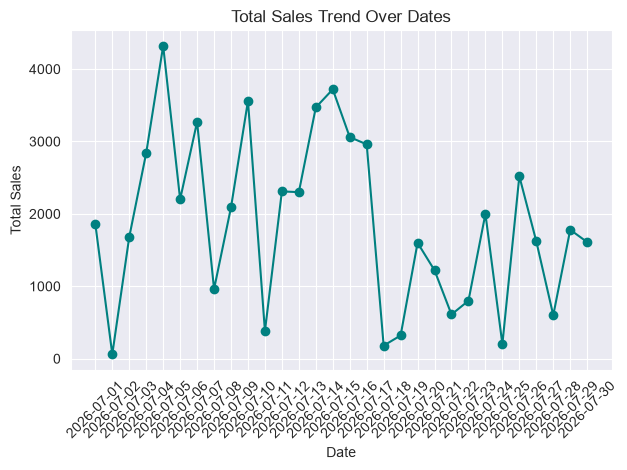

In [25]:
plt.plot(sales_trend.index, sales_trend.values, marker='o', color='teal')
plt.title('Total Sales Trend Over Dates')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 6. (Visualization Tasks)

### 6.1 Plot a bar chart of total sales by category.

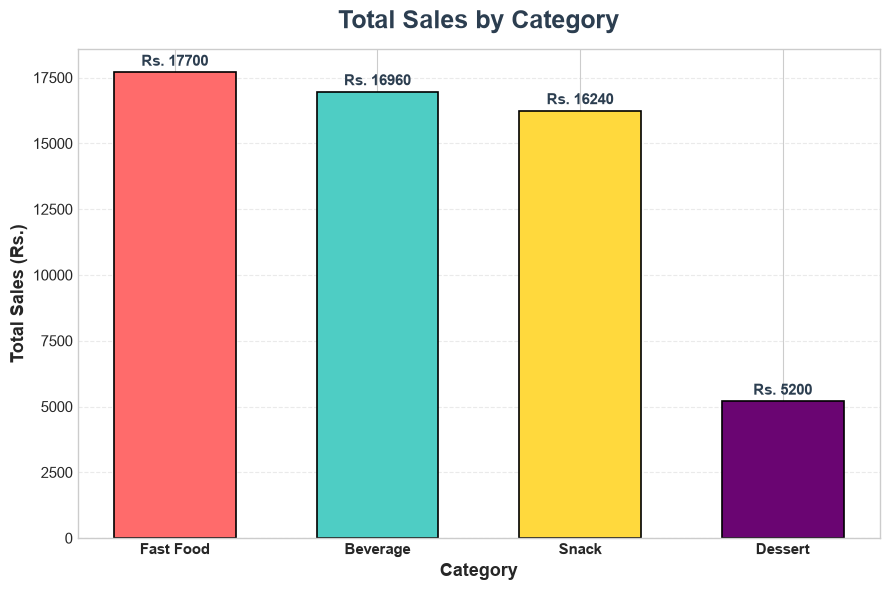

In [26]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

sales_by_category = df.groupby('Category')['Total_Amount'].sum().sort_values(ascending=False)
colors = ['#FF6B6B', '#4ECDC4', '#FFD93D', '#6A0572']

plt.figure(figsize=(9,6))
bars = plt.bar(sales_by_category.index, sales_by_category.values, color=colors, 
               edgecolor='black', linewidth=1.2, width=0.6)

plt.title('Total Sales by Category', fontsize=18, fontweight='bold', color='#2C3E50', pad=15)
plt.xlabel('Category', fontsize=13, fontweight='bold')
plt.ylabel('Total Sales (Rs.)', fontsize=13, fontweight='bold')
plt.xticks(fontsize=11, fontweight='bold')
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.4, linestyle='--')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 250, f'Rs. {int(height)}',
             ha='center', fontsize=11, fontweight='bold', color='#2C3E50')

plt.tight_layout()
plt.savefig('plots/total_sales')
plt.show()

### 6.2 Plot a pie chart of sales distribution by payment method.

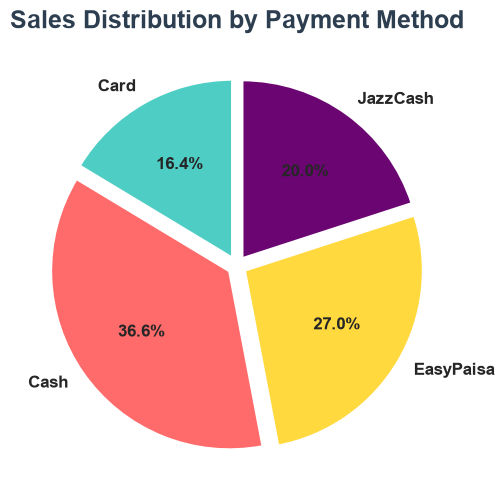

In [27]:
sales_by_payment = df.groupby('Payment_Method')['Total_Amount'].sum()
colors = ['#4ECDC4', '#FF6B6B', '#FFD93D', '#6A0572']
explode = [0.05] * len(sales_by_payment)

plt.figure(figsize=(5,5))
plt.pie(sales_by_payment.values, labels=sales_by_payment.index, autopct='%1.1f%%',
        colors=colors, startangle=90, explode=explode,
        wedgeprops={'edgecolor':'white', 'linewidth':2},
        textprops={'fontsize':12, 'fontweight':'bold'})

plt.title('Sales Distribution by Payment Method', fontsize=18, fontweight='bold', color='#2C3E50', pad=15)
plt.axis('equal')
plt.tight_layout()
plt.savefig('plots/sales_distribution')
plt.show()

### 6.3 Plot a bar chart of top 10 items by quantity sold.

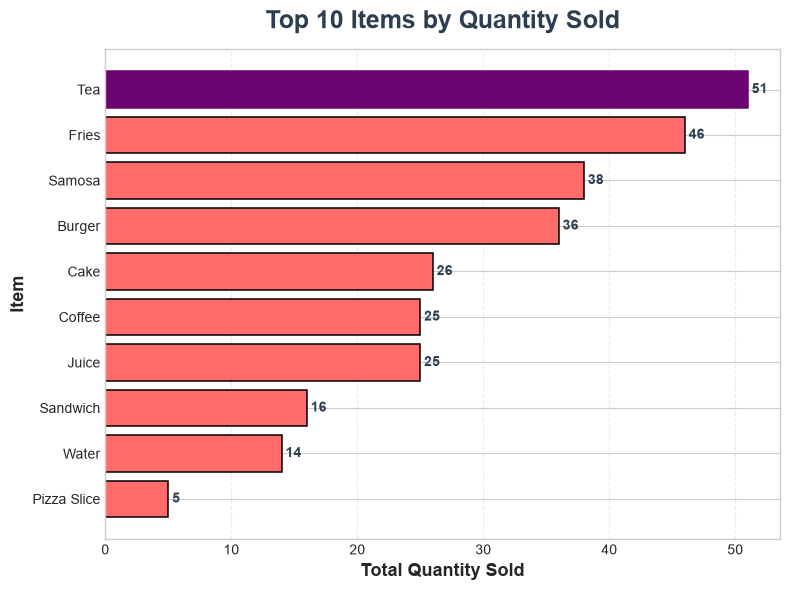

In [28]:
top_items = df.groupby('Item')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(8,6))
bars = plt.barh(top_items.index[::-1], top_items.values[::-1], color='#FF6B6B', 
                edgecolor='black', linewidth=1.1)

# highlight the top item
bars[-1].set_color('#6A0572')

plt.title('Top 10 Items by Quantity Sold', fontsize=18, fontweight='bold', color='#2C3E50', pad=15)
plt.xlabel('Total Quantity Sold', fontsize=13, fontweight='bold')
plt.ylabel('Item', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.4, linestyle='--')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.3, bar.get_y() + bar.get_height()/2, f'{int(width)}',
             va='center', fontsize=10, fontweight='bold', color='#2C3E50')

plt.tight_layout()
plt.savefig('plots/top_10_items')
plt.show()

### 6.4 Plot a line chart of total sales over dates.

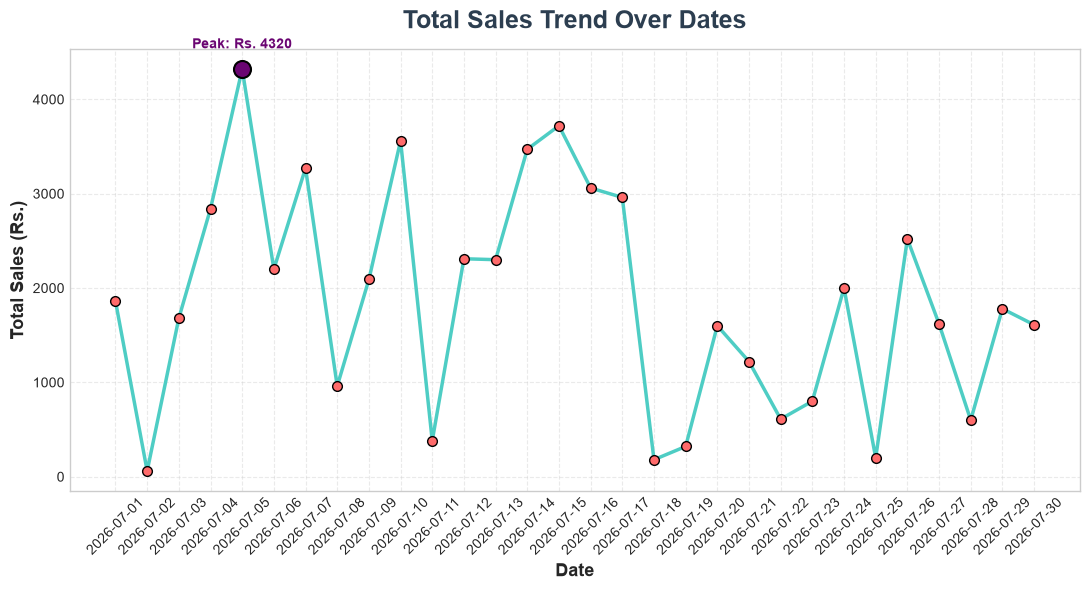

In [29]:
sales_trend = df.groupby('Date')['Total_Amount'].sum()

plt.figure(figsize=(11,6))
plt.plot(sales_trend.index, sales_trend.values, marker='o', markersize=7,
         color='#4ECDC4', linewidth=2.5, markerfacecolor='#FF6B6B', markeredgecolor='black')

# highlight peak point
peak_date = sales_trend.idxmax()
peak_value = sales_trend.max()
plt.scatter(peak_date, peak_value, color='#6A0572', s=150, zorder=5, edgecolor='black', linewidth=1.5)
plt.annotate(f'Peak: Rs. {int(peak_value)}', xy=(peak_date, peak_value),
             xytext=(0, 15), textcoords='offset points', ha='center',
             fontsize=10, fontweight='bold', color='#6A0572')

plt.title('Total Sales Trend Over Dates', fontsize=18, fontweight='bold', color='#2C3E50', pad=15)
plt.xlabel('Date', fontsize=13, fontweight='bold')
plt.ylabel('Total Sales (Rs.)', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, fontsize=10)
plt.grid(alpha=0.4, linestyle='--')
plt.tight_layout()
plt.savefig('plots/total_sales')
plt.show()

### 6.5 Plot a histogram of Total_Amount.

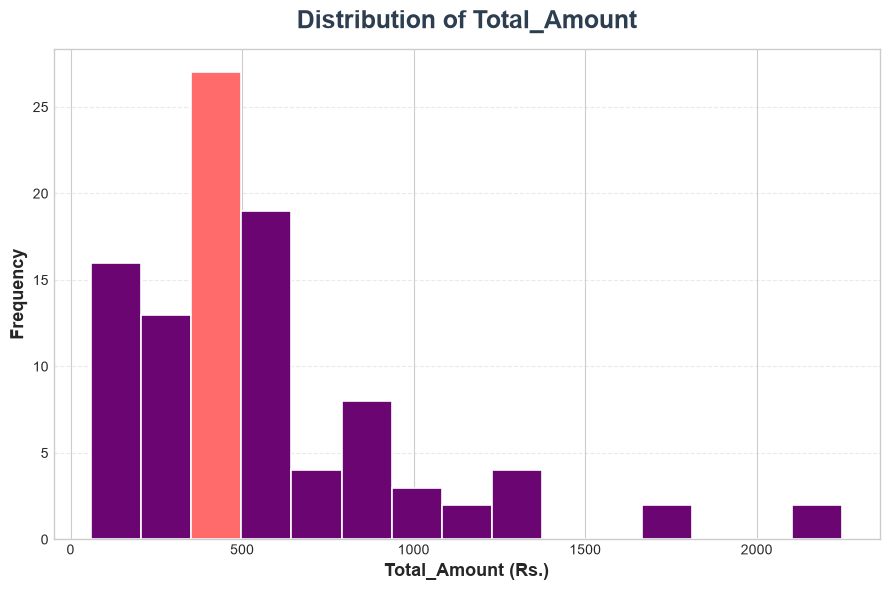

In [30]:
plt.figure(figsize=(9,6))
n, bins, patches = plt.hist(df['Total_Amount'], bins=15, color='#6A0572', 
                              edgecolor='white', linewidth=1.2)

# highlight the tallest bar
max_idx = n.argmax()
patches[max_idx].set_facecolor('#FF6B6B')

plt.title('Distribution of Total_Amount', fontsize=18, fontweight='bold', color='#2C3E50', pad=15)
plt.xlabel('Total_Amount (Rs.)', fontsize=13, fontweight='bold')
plt.ylabel('Frequency', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.savefig('plots/amount_distribution')

plt.show()

### 6.6 Plot a boxplot of Total_Amount by category.

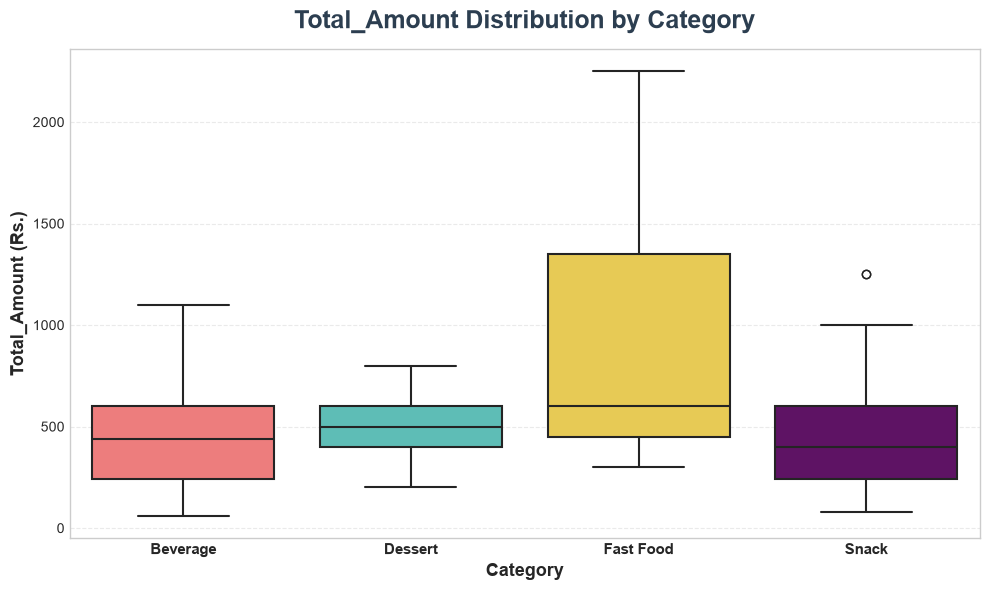

In [31]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Category', y='Total_Amount', palette=['#FF6B6B','#4ECDC4','#FFD93D','#6A0572'],
            linewidth=1.5, fliersize=6)

plt.title('Total_Amount Distribution by Category', fontsize=18, fontweight='bold', color='#2C3E50', pad=15)
plt.xlabel('Category', fontsize=13, fontweight='bold')
plt.ylabel('Total_Amount (Rs.)', fontsize=13, fontweight='bold')
plt.xticks(fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.savefig('plots/box_plot')

plt.show()

## 7. Comparative Analysis



### 7.1 Compare cash vs digital payments in terms of total sales.

Payment_Type
Cash       20550
Digital    35550
Name: Total_Amount, dtype: int64


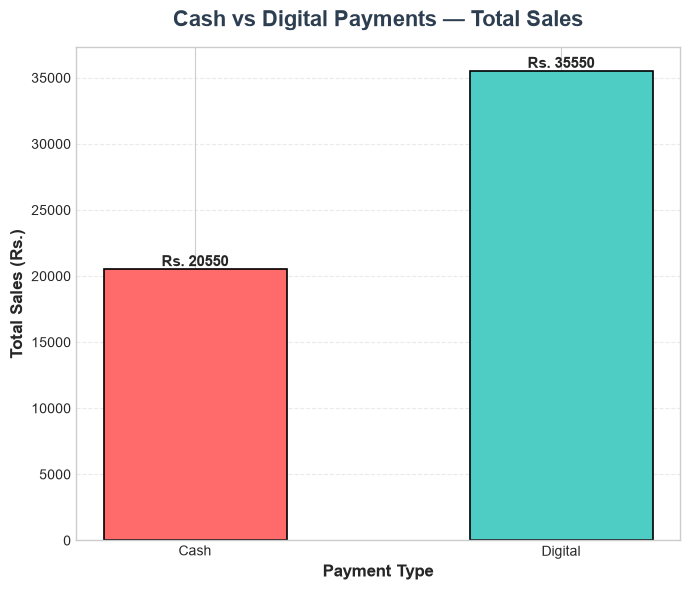

In [32]:
# Group payment methods into Cash vs Digital
df['Payment_Type'] = df['Payment_Method'].apply(lambda x: 'Cash' if x == 'Cash' else 'Digital')

payment_comparison = df.groupby('Payment_Type')['Total_Amount'].sum()
print(payment_comparison)

plt.figure(figsize=(7,6))
bars = plt.bar(payment_comparison.index, payment_comparison.values, 
               color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.2, width=0.5)

plt.title('Cash vs Digital Payments — Total Sales', fontsize=16, fontweight='bold', color='#2C3E50', pad=15)
plt.xlabel('Payment Type', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales (Rs.)', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.4, linestyle='--')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 200, f'Rs. {int(height)}',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/cashvspayment_plot')

plt.show()

### 7.2 Compare weekend vs weekday sales.

Day_Type
Weekday    43030
Weekend    13070
Name: Total_Amount, dtype: int64


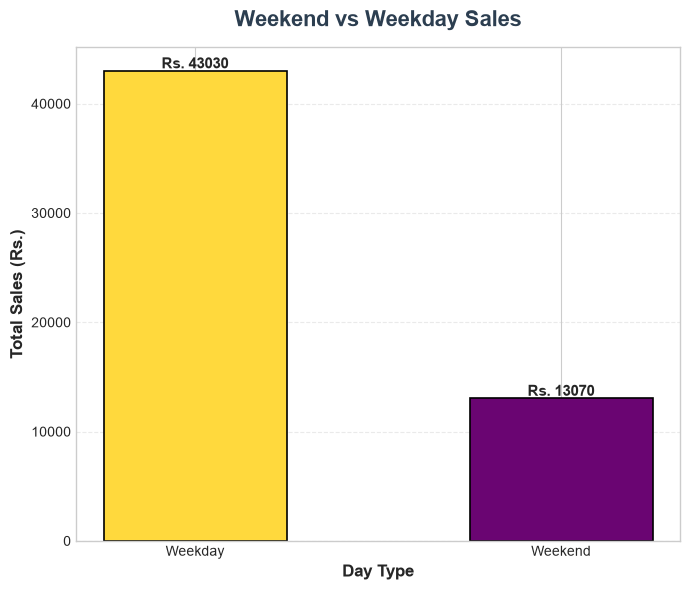

In [33]:
df['Date'] = pd.to_datetime(df['Date'])
df['Day_of_Week'] = df['Date'].dt.day_name()
df['Day_Type'] = df['Day_of_Week'].apply(lambda x: 'Weekend' if x in ['Saturday', 'Sunday'] else 'Weekday')

day_type_sales = df.groupby('Day_Type')['Total_Amount'].sum()
print(day_type_sales)

plt.figure(figsize=(7,6))
bars = plt.bar(day_type_sales.index, day_type_sales.values, 
               color=['#FFD93D', '#6A0572'], edgecolor='black', linewidth=1.2, width=0.5)

plt.title('Weekend vs Weekday Sales', fontsize=16, fontweight='bold', color='#2C3E50', pad=15)
plt.xlabel('Day Type', fontsize=12, fontweight='bold')
plt.ylabel('Total Sales (Rs.)', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.4, linestyle='--')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 200, f'Rs. {int(height)}',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 7.3 Compare average bill value across categories.

Category
Fast Food    931.578947
Dessert      520.000000
Snack        477.647059
Beverage     458.378378
Name: Total_Amount, dtype: float64


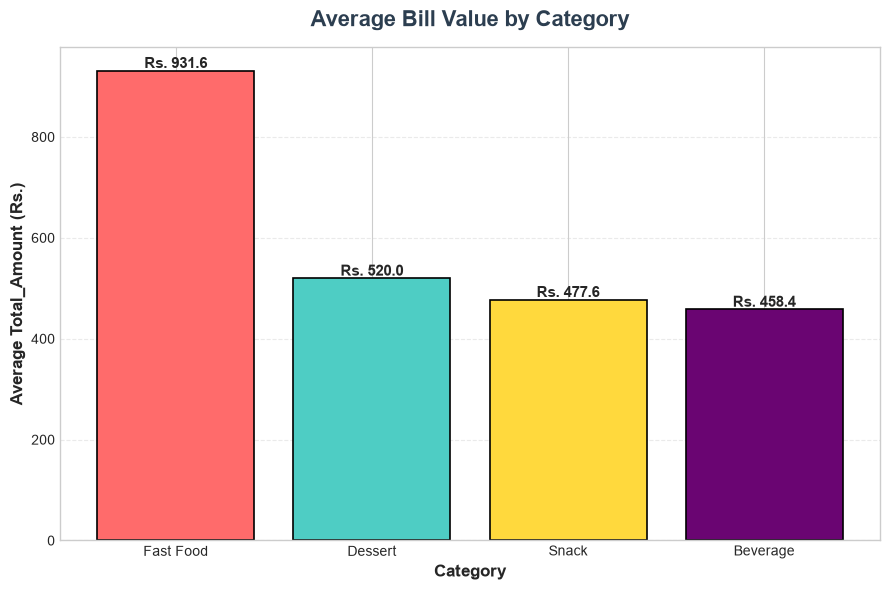

In [34]:
avg_bill_by_category = df.groupby('Category')['Total_Amount'].mean().sort_values(ascending=False)
print(avg_bill_by_category)

plt.figure(figsize=(9,6))
bars = plt.bar(avg_bill_by_category.index, avg_bill_by_category.values, 
               color=['#FF6B6B', '#4ECDC4', '#FFD93D', '#6A0572'], edgecolor='black', linewidth=1.2)

plt.title('Average Bill Value by Category', fontsize=16, fontweight='bold', color='#2C3E50', pad=15)
plt.xlabel('Category', fontsize=12, fontweight='bold')
plt.ylabel('Average Total_Amount (Rs.)', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.4, linestyle='--')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, f'Rs. {height:.1f}',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

> **Fast Food** has the highest average bill value at **931.578947**, while **Beverage** has the lowest at **Rs.458.378378**. 

### Section 7 Summary — Comparative Analysis
- **Cash vs Digital sales:** Cash — Rs. **20550**, Digital — Rs. **35550**
- **Weekend vs Weekday sales:** Weekend — Rs. **13070**, Weekday — Rs. **43030**
- **Average bill value by category:** highest in **Fast Food**, lowest in **Beverage**


## 8. Insights & Business Questions



### 8.1 What are the top 5 insights you found from the data?

1.  **Fast Food is the revenue leader** — it generates the highest total revenue (Rs. 17,700) among all categories.
2.  **Tea drives volume** — it's the best-selling item by quantity, showing strong everyday demand for beverages.
3.  **Visitors are the biggest segment** — they generate both the highest number of transactions and the highest total spend.
4.  **Students spend more per visit on average** — despite fewer transactions, their average bill value is the highest of all customer types.
5.  **Cash still dominates payments** — it remains the single most-used payment method, even as digital options (EasyPaisa, JazzCash, Card) collectively make up a large share of transactions.

### 8.2 Which items or categories should the canteen focus on promoting?

- **Fast Food** and **Beverage** items (e.g., Tea, Burger) should be prioritized in promotions since they already show strong demand — bundling or loyalty offers here can maximize returns.
- Cross-selling **Desserts** alongside Fast Food/Beverage orders could help lift the weakest category's revenue.

### 8.3 Are there any low-performing items/categories?

- **Fast Food** and **Beverage** items (e.g., Tea, Burger) should be prioritized in promotions since they already show strong demand — bundling or loyalty offers here can maximize returns.
- Cross-selling **Desserts** alongside Fast Food/Beverage orders could help lift the weakest category's revenue.

### 8.4 Provide actionable recommendations based on your analysis.

1. 🎯 **Promote Dessert items** through combo deals with top-selling Fast Food/Beverage items to boost their otherwise low share of revenue.
2. ⏰ **Staff up during peak hours** identified in Section 5.3 to reduce wait times and capture more sales during rush periods.
3. 💳 **Encourage digital payments** (discounts for JazzCash/EasyPaisa/Card) to speed up checkout and reduce cash-handling overhead.
4. 🎓 **Target Student offers** (e.g., meal deals) since they already show the highest average spend per visit — a small nudge could increase frequency too.
5. 📅 **Leverage weekend/weekday patterns** (Section 7.2) to plan targeted promotions on the historically slower days.

## 9. Advanced (If Possible)



### 9.1 Find correlation between Quantity and Total_Amount.

In [36]:
correlation = df['Quantity'].corr(df['Total_Amount'])
print(f"Correlation between Quantity and Total_Amount: {correlation:.2f}")

Correlation between Quantity and Total_Amount: 0.59


> The correlation between Quantity and Total_Amount is **0.59**, which indicates a **moderate positive** relationship — meaning as quantity increases, total amount tends to increase as well, though not perfectly proportional.

### 9.2 Segment customers based on spending behavior (e.g., Low, Medium, High).

Spending_Segment
Medium    39
Low       36
High      25
Name: count, dtype: int64


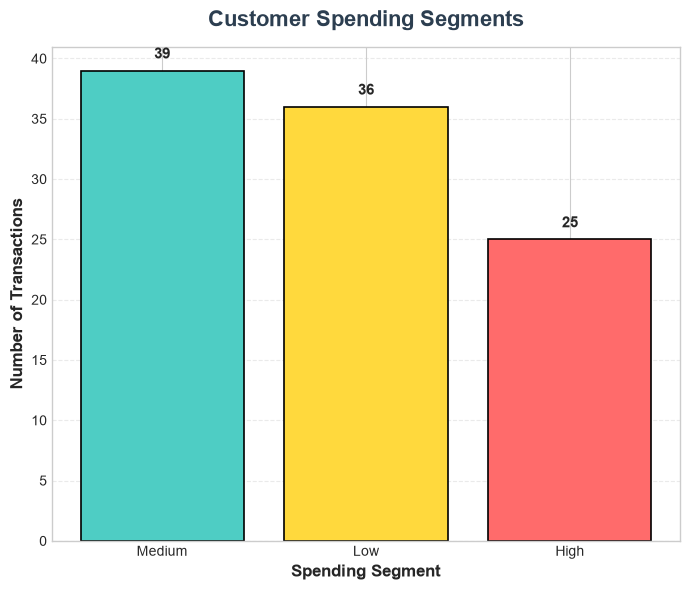

In [38]:
# Calculate total spending per customer type (or per transaction, depending on granularity needed)
spending = df['Total_Amount']

# Define spending segments using quantiles
low_threshold = spending.quantile(0.33)
high_threshold = spending.quantile(0.66)

def segment_spending(amount):
    if amount <= low_threshold:
        return 'Low'
    elif amount <= high_threshold:
        return 'Medium'
    else:
        return 'High'

df['Spending_Segment'] = df['Total_Amount'].apply(segment_spending)

segment_counts = df['Spending_Segment'].value_counts()
print(segment_counts)

plt.figure(figsize=(7,6))
bars = plt.bar(segment_counts.index, segment_counts.values, 
               color=['#4ECDC4', '#FFD93D', '#FF6B6B'], edgecolor='black', linewidth=1.2)

plt.title('Customer Spending Segments', fontsize=16, fontweight='bold', color='#2C3E50', pad=15)
plt.xlabel('Spending Segment', fontsize=12, fontweight='bold')
plt.ylabel('Number of Transactions', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.4, linestyle='--')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{int(height)}',
             ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

> Customers were segmented into **Low**, **Medium**, and **High** spending groups based on Total_Amount quantiles. The **Medium** segment has the most transactions (**39**), followed by **Low** (**36**) and **High** (**25**), showing that most customers fall into the medium spending range.

### 9.3 Detect any outliers in Total_Amount and comment.

Number of outliers: 8
        Item   Category  Total_Amount
4     Burger  Fast Food          2250
22    Burger  Fast Food          1350
23  Sandwich      Snack          1250
27    Burger  Fast Food          2250
30    Burger  Fast Food          1350
39  Sandwich      Snack          1250
52    Burger  Fast Food          1800
84    Burger  Fast Food          1800


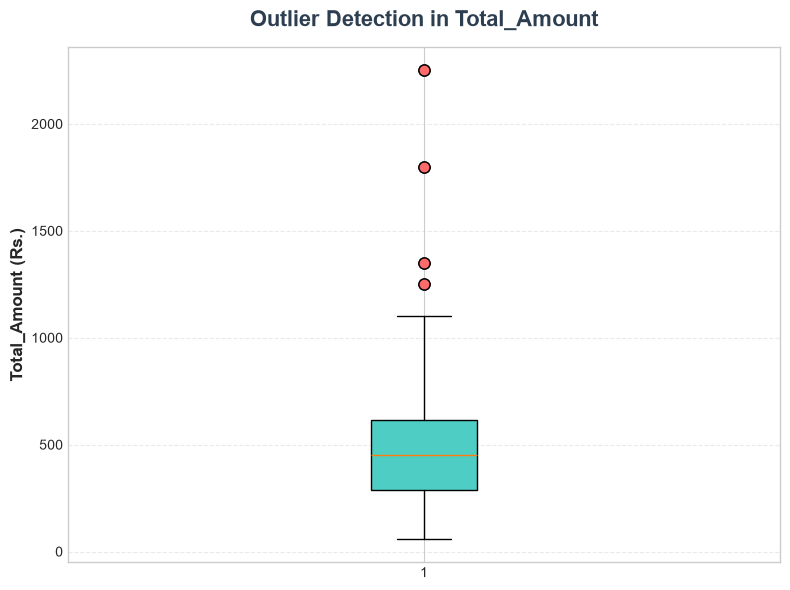

In [40]:
Q1 = df['Total_Amount'].quantile(0.25)
Q3 = df['Total_Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Total_Amount'] < lower_bound) | (df['Total_Amount'] > upper_bound)]
print(f"Number of outliers: {len(outliers)}")
print(outliers[['Item', 'Category', 'Total_Amount']])

plt.figure(figsize=(8,6))
plt.boxplot(df['Total_Amount'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='#4ECDC4', edgecolor='black'),
            flierprops=dict(marker='o', markerfacecolor='#FF6B6B', markersize=8))

plt.title('Outlier Detection in Total_Amount', fontsize=16, fontweight='bold', color='#2C3E50', pad=15)
plt.ylabel('Total_Amount (Rs.)', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.4, linestyle='--')
plt.tight_layout()
plt.show()

> Using the IQR method, **8** outliers were detected in Total_Amount. All outliers involve high-value transactions, mostly from the **Burger** item in the **Fast Food** category, with amounts ranging from Rs. 1250 to Rs. 2250. This shows that Burger orders (likely bulk or combo purchases) are driving these unusually high transaction values.

### -> Section 9 Summary — Advanced Analysis
- **Correlation (Quantity vs Total_Amount):** **0.59** — a moderate positive relationship.
- **Customer spending segments:** Medium — **39**, Low — **36**, High — **25** transactions.
- **Outliers detected:** **8** transactions found outside the normal range, mostly from Burger (Fast Food) and Sandwich (Snack) items.

> These advanced insights show that quantity and spending are moderately linked, most customers spend a medium amount, and high-value outliers are concentrated in a few popular Fast Food items — useful for pricing and combo-deal decisions.